# Automotive Component Detection — Complete Experiment Pipeline
**Title:** Improving Detection of Visually Challenging Automotive Components

**All 6 experiments in one notebook — optimised for Kaggle/Colab GPU**

| Exp | What | Est. Time | Status |
|-----|------|-----------|--------|
| 1 | Baseline YOLOv8s | ~45 min | Done (Colab) |
| 2 | Architecture: YOLOv8n/s/m | ~2 hrs | Done (Colab) |
| 3 | Resolution: 320/640/800 | ~2 hrs | Run this |
| 4 | Augmentation: none/standard/advanced | ~2 hrs | Run this |
| 5 | Transfer learning: pretrained vs scratch | ~1.5 hrs | Run this |
| 6 | YOLO26s vs YOLOv8s | ~1 hr | Run this |



## Setup — run this every session

In [1]:
!pip install ultralytics roboflow -q

import torch, os, json, time, glob, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from collections import Counter
from ultralytics import YOLO

# GPU check
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("NO GPU — enable it in Settings!")

# Detect platform
if os.path.exists('/kaggle'):
    PLATFORM = 'kaggle'
    BASE_DIR = '/kaggle/working'
elif os.path.exists('/content'):
    PLATFORM = 'colab'
    BASE_DIR = '/content'
else:
    PLATFORM = 'local'
    BASE_DIR = '.'

DATASET_DIR = f'{BASE_DIR}/dataset'
OUTPUT_DIR = f'{BASE_DIR}/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Platform: {PLATFORM}")
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.5 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Upd

In [2]:
# Download dataset
if os.path.exists(f'{DATASET_DIR}/data.yaml'):
    print("Dataset already exists.")
else:
    from roboflow import Roboflow
    rf = Roboflow(api_key="HflL48lLaUJcggGlWRtj")
    project = rf.workspace("team-data").project("car-parts-ybiev")
    version = project.version(1)
    dataset = version.download("yolov8", location=DATASET_DIR)

# Find data.yaml (Roboflow sometimes nests it)
DATA_YAML = None
for root, dirs, files in os.walk(DATASET_DIR):
    if 'data.yaml' in files:
        DATA_YAML = os.path.join(root, 'data.yaml')
        break

if DATA_YAML:
    print(f"data.yaml found: {DATA_YAML}")
    with open(DATA_YAML, 'r') as f:
        config = yaml.safe_load(f)
    CLASS_NAMES = config['names']
    print(f"Classes: {len(CLASS_NAMES)}")
else:
    print("ERROR: data.yaml not found!")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/dataset in yolov8:: 100%|██████████| 23608/23608 [00:02<00:00, 9490.35it/s] 


data.yaml found: /kaggle/working/dataset/data.yaml
Classes: 50


In [3]:
# Hard classes from baseline results
HARD_CLASSES = ['IGNITION COIL', 'GAS CAP', 'DISTRIBUTOR', 'OVERFLOW TANK', 'OIL PRESSURE SENSOR']

# Shared training settings — optimised for speed
EPOCHS = 50
PATIENCE = 10

def train_and_evaluate(model_name, experiment_name, extra_args={}):
    """Train a model and return per-class results. Reusable for all experiments."""
    model = YOLO(model_name)
    start = time.time()
    
    train_args = {
        'data': DATA_YAML,
        'epochs': EPOCHS,
        'patience': PATIENCE,
        'batch': 16,
        'imgsz': 640,
        'device': 0,
        'save': True,
        'plots': True,
        'project': f'{OUTPUT_DIR}/runs',
        'name': experiment_name,
        'exist_ok': True,
    }
    train_args.update(extra_args)
    
    model.train(**train_args)
    train_time = time.time() - start
    
    # Evaluate on test set
    best_path = f'{OUTPUT_DIR}/runs/{experiment_name}/weights/best.pt'
    best = YOLO(best_path)
    imgsz = extra_args.get('imgsz', 640)
    val = best.val(data=DATA_YAML, split='test', imgsz=imgsz)
    
    # Extract results
    results = {
        'overall': {
            'mAP50': round(float(val.box.map50), 4),
            'mAP50_95': round(float(val.box.map), 4),
            'precision': round(float(val.box.mp), 4),
            'recall': round(float(val.box.mr), 4),
        },
        'per_class': {},
        'training_time_min': round(train_time / 60, 1),
    }
    for i, name in enumerate(CLASS_NAMES):
        if i < len(val.box.ap50):
            results['per_class'][name] = {
                'mAP50': round(float(val.box.ap50[i]), 4),
            }
    
    # Print hard classes
    print(f"\n{'='*55}")
    print(f"{experiment_name} | Overall mAP@0.5: {results['overall']['mAP50']} | Time: {results['training_time_min']}min")
    print(f"{'='*55}")
    print(f"{'Hard Class':<25} {'mAP50':>8}")
    print('-'*35)
    for cls in HARD_CLASSES:
        if cls in results['per_class']:
            print(f"{cls:<25} {results['per_class'][cls]['mAP50']:>8}")
    
    return results

print("Helper function ready.")

Helper function ready.


---
## Experiment 3: Resolution Impact (RQ2)
**Does higher input resolution improve detection of visually challenging components?**

Testing: 320px vs 640px vs 800px | Model: YOLOv8s | Est: ~2 hours

In [4]:
exp3_results = {}

for imgsz in [320, 640, 800]:
    print(f"\n>>> Resolution: {imgsz}px")
    batch = 16 if imgsz <= 640 else 8
    
    exp3_results[str(imgsz)] = train_and_evaluate(
        model_name='yolov8s.pt',
        experiment_name=f'exp3_res{imgsz}',
        extra_args={'imgsz': imgsz, 'batch': batch}
    )

with open(f'{OUTPUT_DIR}/exp3_resolution.json', 'w') as f:
    json.dump(exp3_results, f, indent=2)

print("\n\nRESOLUTION COMPARISON:")
for res, data in exp3_results.items():
    print(f"  {res}px: mAP@0.5 = {data['overall']['mAP50']}, Time = {data['training_time_min']}min")


>>> Resolution: 320px
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_res320, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

---
## Experiment 4: Augmentation Strategies (RQ3)
**Which augmentations help the most for hard-to-detect parts?**

Testing: No augmentation vs Standard vs Advanced (mosaic+mixup) | Est: ~2 hours

In [5]:
aug_configs = {
    'no_aug': {
        'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.0,
        'degrees': 0.0, 'translate': 0.0, 'scale': 0.0,
        'fliplr': 0.0, 'mosaic': 0.0, 'mixup': 0.0,
    },
    'standard_aug': {
        'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
        'degrees': 10.0, 'translate': 0.1, 'scale': 0.5,
        'fliplr': 0.5, 'mosaic': 0.0, 'mixup': 0.0,
    },
    'advanced_aug': {
        'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
        'degrees': 15.0, 'translate': 0.1, 'scale': 0.5,
        'fliplr': 0.5, 'mosaic': 1.0, 'mixup': 0.15,
    },
}

exp4_results = {}

for name, params in aug_configs.items():
    print(f"\n>>> Augmentation: {name}")
    exp4_results[name] = train_and_evaluate(
        model_name='yolov8s.pt',
        experiment_name=f'exp4_{name}',
        extra_args=params
    )

with open(f'{OUTPUT_DIR}/exp4_augmentation.json', 'w') as f:
    json.dump(exp4_results, f, indent=2)

print("\n\nAUGMENTATION COMPARISON:")
for name, data in exp4_results.items():
    print(f"  {name}: mAP@0.5 = {data['overall']['mAP50']}")


>>> Augmentation: no_aug
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=exp4_no_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

---
## Experiment 5: Transfer Learning vs From Scratch (RQ2)
**Does COCO pretraining help or hurt hard classes?**

Testing: Pretrained weights vs Random initialisation | Est: ~1.5 hours

In [4]:
exp5_results = {}

# Pretrained (COCO weights)
print(">>> Transfer learning: pretrained (COCO)")
exp5_results['pretrained'] = train_and_evaluate(
    model_name='yolov8s.pt',
    experiment_name='exp5_pretrained'
)

# From scratch (random weights)
print("\n>>> Transfer learning: from scratch")
exp5_results['from_scratch'] = train_and_evaluate(
    model_name='yolov8s.yaml',
    experiment_name='exp5_from_scratch',
    extra_args={'epochs': 80, 'patience': 15}  # needs more epochs to converge
)

with open(f'{OUTPUT_DIR}/exp5_transfer_learning.json', 'w') as f:
    json.dump(exp5_results, f, indent=2)

print("\n\nTRANSFER LEARNING COMPARISON:")
for name, data in exp5_results.items():
    print(f"  {name}: mAP@0.5 = {data['overall']['mAP50']}, Time = {data['training_time_min']}min")

>>> Transfer learning: pretrained (COCO)
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp5_pretrained, nbs=64, nms=False, opset=None, optimize=Fals

---
## Experiment 6: YOLO26 vs YOLOv8 (Cross-Generational Comparison)
**Does the latest YOLO with Small-Target-Aware training improve hard classes?**

YOLO26 released Sep 2025 — very few studies have tested it on domain-specific data.
This adds genuine novelty to your dissertation. | Est: ~1 hour

In [5]:
exp6_results = {}

print(">>> YOLO26s training")
exp6_results['yolo26s'] = train_and_evaluate(
    model_name='yolo26s.pt',
    experiment_name='exp6_yolo26s'
)

with open(f'{OUTPUT_DIR}/exp6_yolo26.json', 'w') as f:
    json.dump(exp6_results, f, indent=2)

print(f"\nYOLO26s: mAP@0.5 = {exp6_results['yolo26s']['overall']['mAP50']}")
print(f"Compare with YOLOv8s baseline: mAP@0.5 = 0.936")

>>> YOLO26s training
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp6_yolo26s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

---
## Results Analysis — run after ALL experiments complete

In [6]:
# Load all results
all_results = {}
for f_path in sorted(glob.glob(f'{OUTPUT_DIR}/exp*.json')):
    exp_name = os.path.basename(f_path).replace('.json', '')
    with open(f_path, 'r') as f:
        all_results[exp_name] = json.load(f)
    print(f"Loaded: {exp_name}")

# Build comparison table
rows = []
for exp_name, exp_data in all_results.items():
    if 'overall' in exp_data:
        rows.append({'Experiment': exp_name, **exp_data['overall']})
    else:
        for variant, vdata in exp_data.items():
            if isinstance(vdata, dict) and 'overall' in vdata:
                rows.append({'Experiment': f"{exp_name}/{variant}", **vdata['overall']})

df = pd.DataFrame(rows)
print("\n" + "="*70)
print("COMPLETE EXPERIMENT COMPARISON")
print("="*70)
print(df.to_string(index=False))
df.to_csv(f'{OUTPUT_DIR}/all_experiments_comparison.csv', index=False)

Loaded: exp5_transfer_learning
Loaded: exp6_yolo26

COMPLETE EXPERIMENT COMPARISON
                         Experiment  mAP50  mAP50_95  precision  recall
  exp5_transfer_learning/pretrained 0.9368    0.9368     0.9025  0.8783
exp5_transfer_learning/from_scratch 0.8358    0.8358     0.7844  0.7595
                exp6_yolo26/yolo26s 0.9476    0.9475     0.9123  0.8872



HARD CLASSES — mAP@0.5 ACROSS ALL EXPERIMENTS:
                     exp5_transfer_learning/pretrained  exp5_transfer_learning/from_scratch  exp6_yolo26/yolo26s
IGNITION COIL                                   0.7529                               0.3731               0.7919
GAS CAP                                         0.6848                               0.4422               0.6972
DISTRIBUTOR                                     0.7354                               0.3454               0.8054
OVERFLOW TANK                                   0.8224                               0.6396               0.8572
OIL PRESSURE SENSOR                             0.9362                               0.7598               0.9655


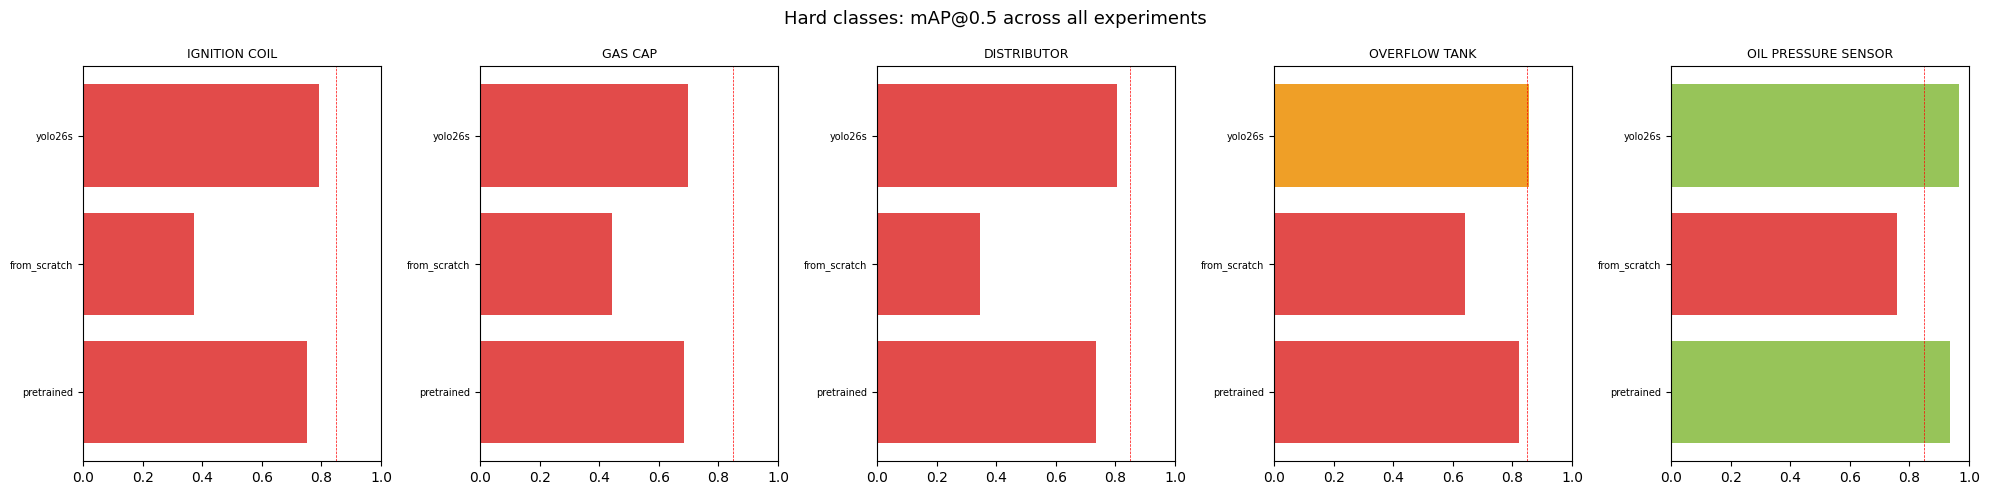

In [7]:
# Hard classes comparison across ALL experiments
hard_data = {}

for exp_name, exp_data in all_results.items():
    if 'per_class' in exp_data:
        label = exp_name
        for cls in HARD_CLASSES:
            if cls in exp_data['per_class']:
                hard_data.setdefault(cls, {})[label] = exp_data['per_class'][cls]['mAP50']
    else:
        for variant, vdata in exp_data.items():
            if isinstance(vdata, dict) and 'per_class' in vdata:
                label = f"{exp_name}/{variant}"
                for cls in HARD_CLASSES:
                    if cls in vdata['per_class']:
                        hard_data.setdefault(cls, {})[label] = vdata['per_class'][cls]['mAP50']

if hard_data:
    df_hard = pd.DataFrame(hard_data).T
    print("\nHARD CLASSES — mAP@0.5 ACROSS ALL EXPERIMENTS:")
    print(df_hard.to_string())
    df_hard.to_csv(f'{OUTPUT_DIR}/hard_classes_comparison.csv')
    
    # Chart
    fig, axes = plt.subplots(1, len(HARD_CLASSES), figsize=(20, 5))
    for i, cls in enumerate(HARD_CLASSES):
        if cls in hard_data:
            exps = list(hard_data[cls].keys())
            vals = list(hard_data[cls].values())
            colors = ['#E24B4A' if v < 0.85 else '#EF9F27' if v < 0.92 else '#97C459' for v in vals]
            axes[i].barh(range(len(exps)), vals, color=colors)
            axes[i].set_yticks(range(len(exps)))
            axes[i].set_yticklabels([e.split('/')[-1] for e in exps], fontsize=7)
            axes[i].set_xlim(0, 1)
            axes[i].set_title(cls, fontsize=9)
            axes[i].axvline(x=0.85, color='red', linestyle='--', linewidth=0.5)
    plt.suptitle('Hard classes: mAP@0.5 across all experiments', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/hard_classes_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

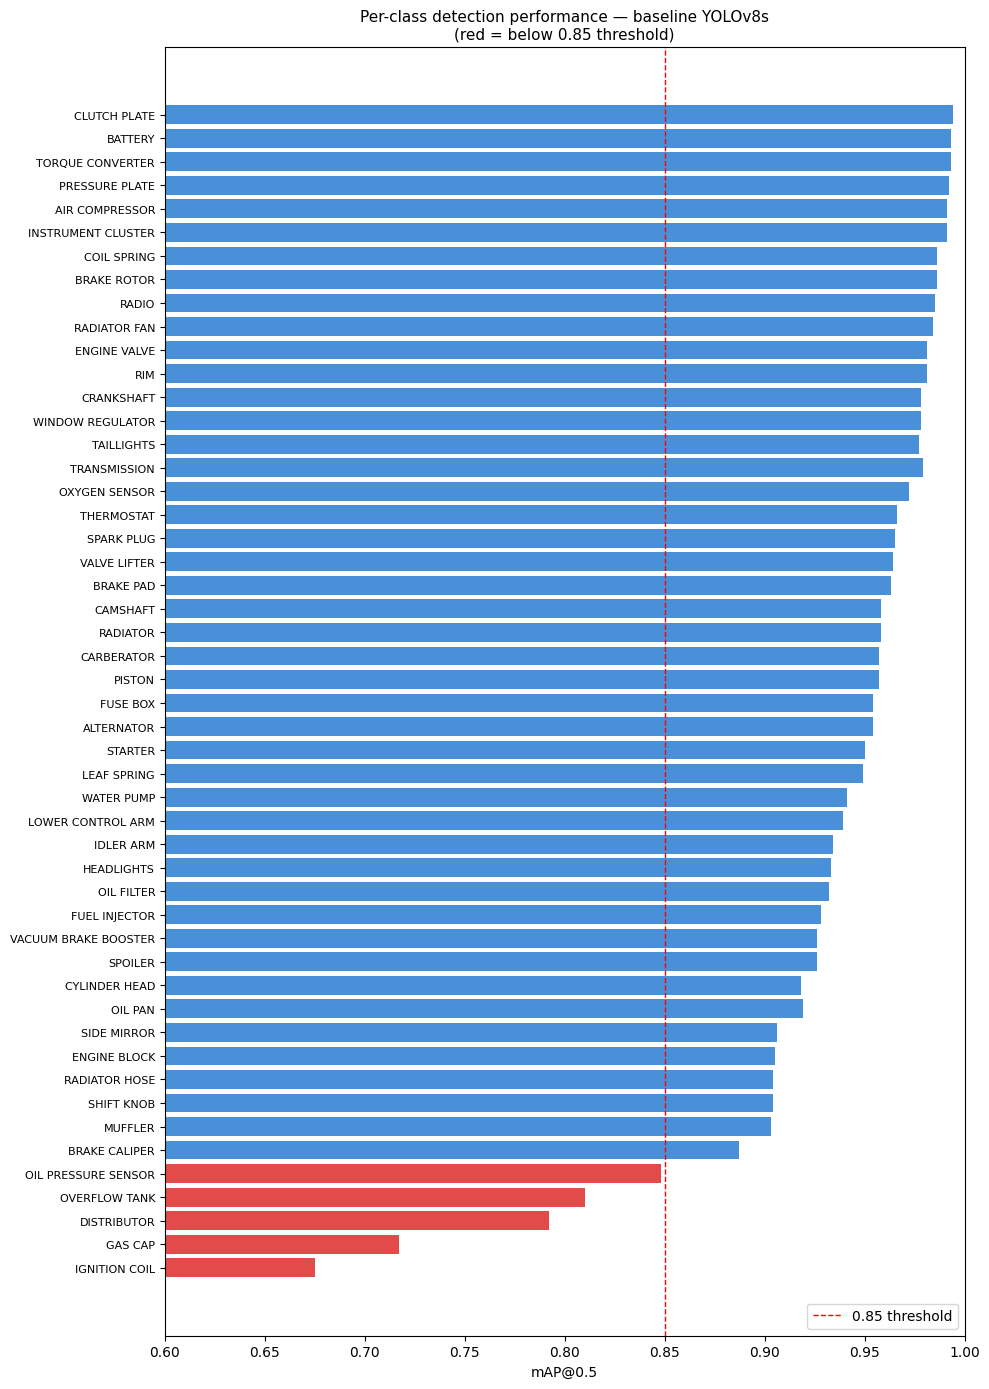

Saved: /kaggle/working/results/ch1_motivational_figure.png


In [8]:
# Per-class baseline chart for Chapter 1 (motivational figure)
# Uses baseline results — update values after running exp1

baseline_per_class = {
    'CLUTCH PLATE': 0.994, 'BATTERY': 0.993, 'TORQUE CONVERTER': 0.993,
    'PRESSURE PLATE': 0.992, 'AIR COMPRESSOR': 0.991,
    'INSTRUMENT CLUSTER': 0.991, 'COIL SPRING': 0.986, 'BRAKE ROTOR': 0.986,
    'RADIO': 0.985, 'RADIATOR FAN': 0.984,
    'ENGINE VALVE': 0.981, 'RIM': 0.981, 'CRANKSHAFT': 0.978,
    'WINDOW REGULATOR': 0.978, 'TAILLIGHTS': 0.977,
    'TRANSMISSION': 0.979, 'OXYGEN SENSOR': 0.972, 'THERMOSTAT': 0.966,
    'SPARK PLUG': 0.965, 'VALVE LIFTER': 0.964,
    'BRAKE PAD': 0.963, 'CAMSHAFT': 0.958, 'RADIATOR': 0.958,
    'CARBERATOR': 0.957, 'PISTON': 0.957,
    'FUSE BOX': 0.954, 'ALTERNATOR': 0.954, 'STARTER': 0.950,
    'LEAF SPRING': 0.949, 'WATER PUMP': 0.941,
    'LOWER CONTROL ARM': 0.939, 'IDLER ARM': 0.934, 'HEADLIGHTS': 0.933,
    'OIL FILTER': 0.932, 'FUEL INJECTOR': 0.928,
    'VACUUM BRAKE BOOSTER': 0.926, 'SPOILER': 0.926, 'CYLINDER HEAD': 0.918,
    'OIL PAN': 0.919, 'SIDE MIRROR': 0.906,
    'ENGINE BLOCK': 0.905, 'RADIATOR HOSE': 0.904, 'SHIFT KNOB': 0.904,
    'MUFFLER': 0.903, 'BRAKE CALIPER': 0.887,
    'OIL PRESSURE SENSOR': 0.848, 'OVERFLOW TANK': 0.810,
    'DISTRIBUTOR': 0.792, 'GAS CAP': 0.717, 'IGNITION COIL': 0.675,
}

names = list(baseline_per_class.keys())
values = list(baseline_per_class.values())
colors = ['#E24B4A' if v < 0.85 else '#4A90D9' for v in values]

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(range(len(names)), values, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.axvline(x=0.85, color='red', linestyle='--', linewidth=1, label='0.85 threshold')
ax.set_xlabel('mAP@0.5')
ax.set_xlim(0.6, 1.0)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.title('Per-class detection performance — baseline YOLOv8s\n(red = below 0.85 threshold)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ch1_motivational_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/ch1_motivational_figure.png")


0: 640x640 1 VACUUM BRAKE BOOSTER, 11.7ms
1: 640x640 1 RADIO, 11.7ms
2: 640x640 1 VALVE LIFTER, 11.7ms
3: 640x640 (no detections), 11.7ms
4: 640x640 1 FUEL INJECTOR, 11.7ms
5: 640x640 1 IDLER ARM, 11.7ms
6: 640x640 1 CRANKSHAFT, 11.7ms
7: 640x640 1 OIL PAN, 11.7ms
8: 640x640 1 OIL PRESSURE SENSOR, 11.7ms
9: 640x640 1 PRESSURE PLATE, 11.7ms
10: 640x640 1 TAILLIGHTS, 11.7ms
11: 640x640 1 TRANSMISSION, 11.7ms
Speed: 1.8ms preprocess, 11.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/results/visualisations/detections


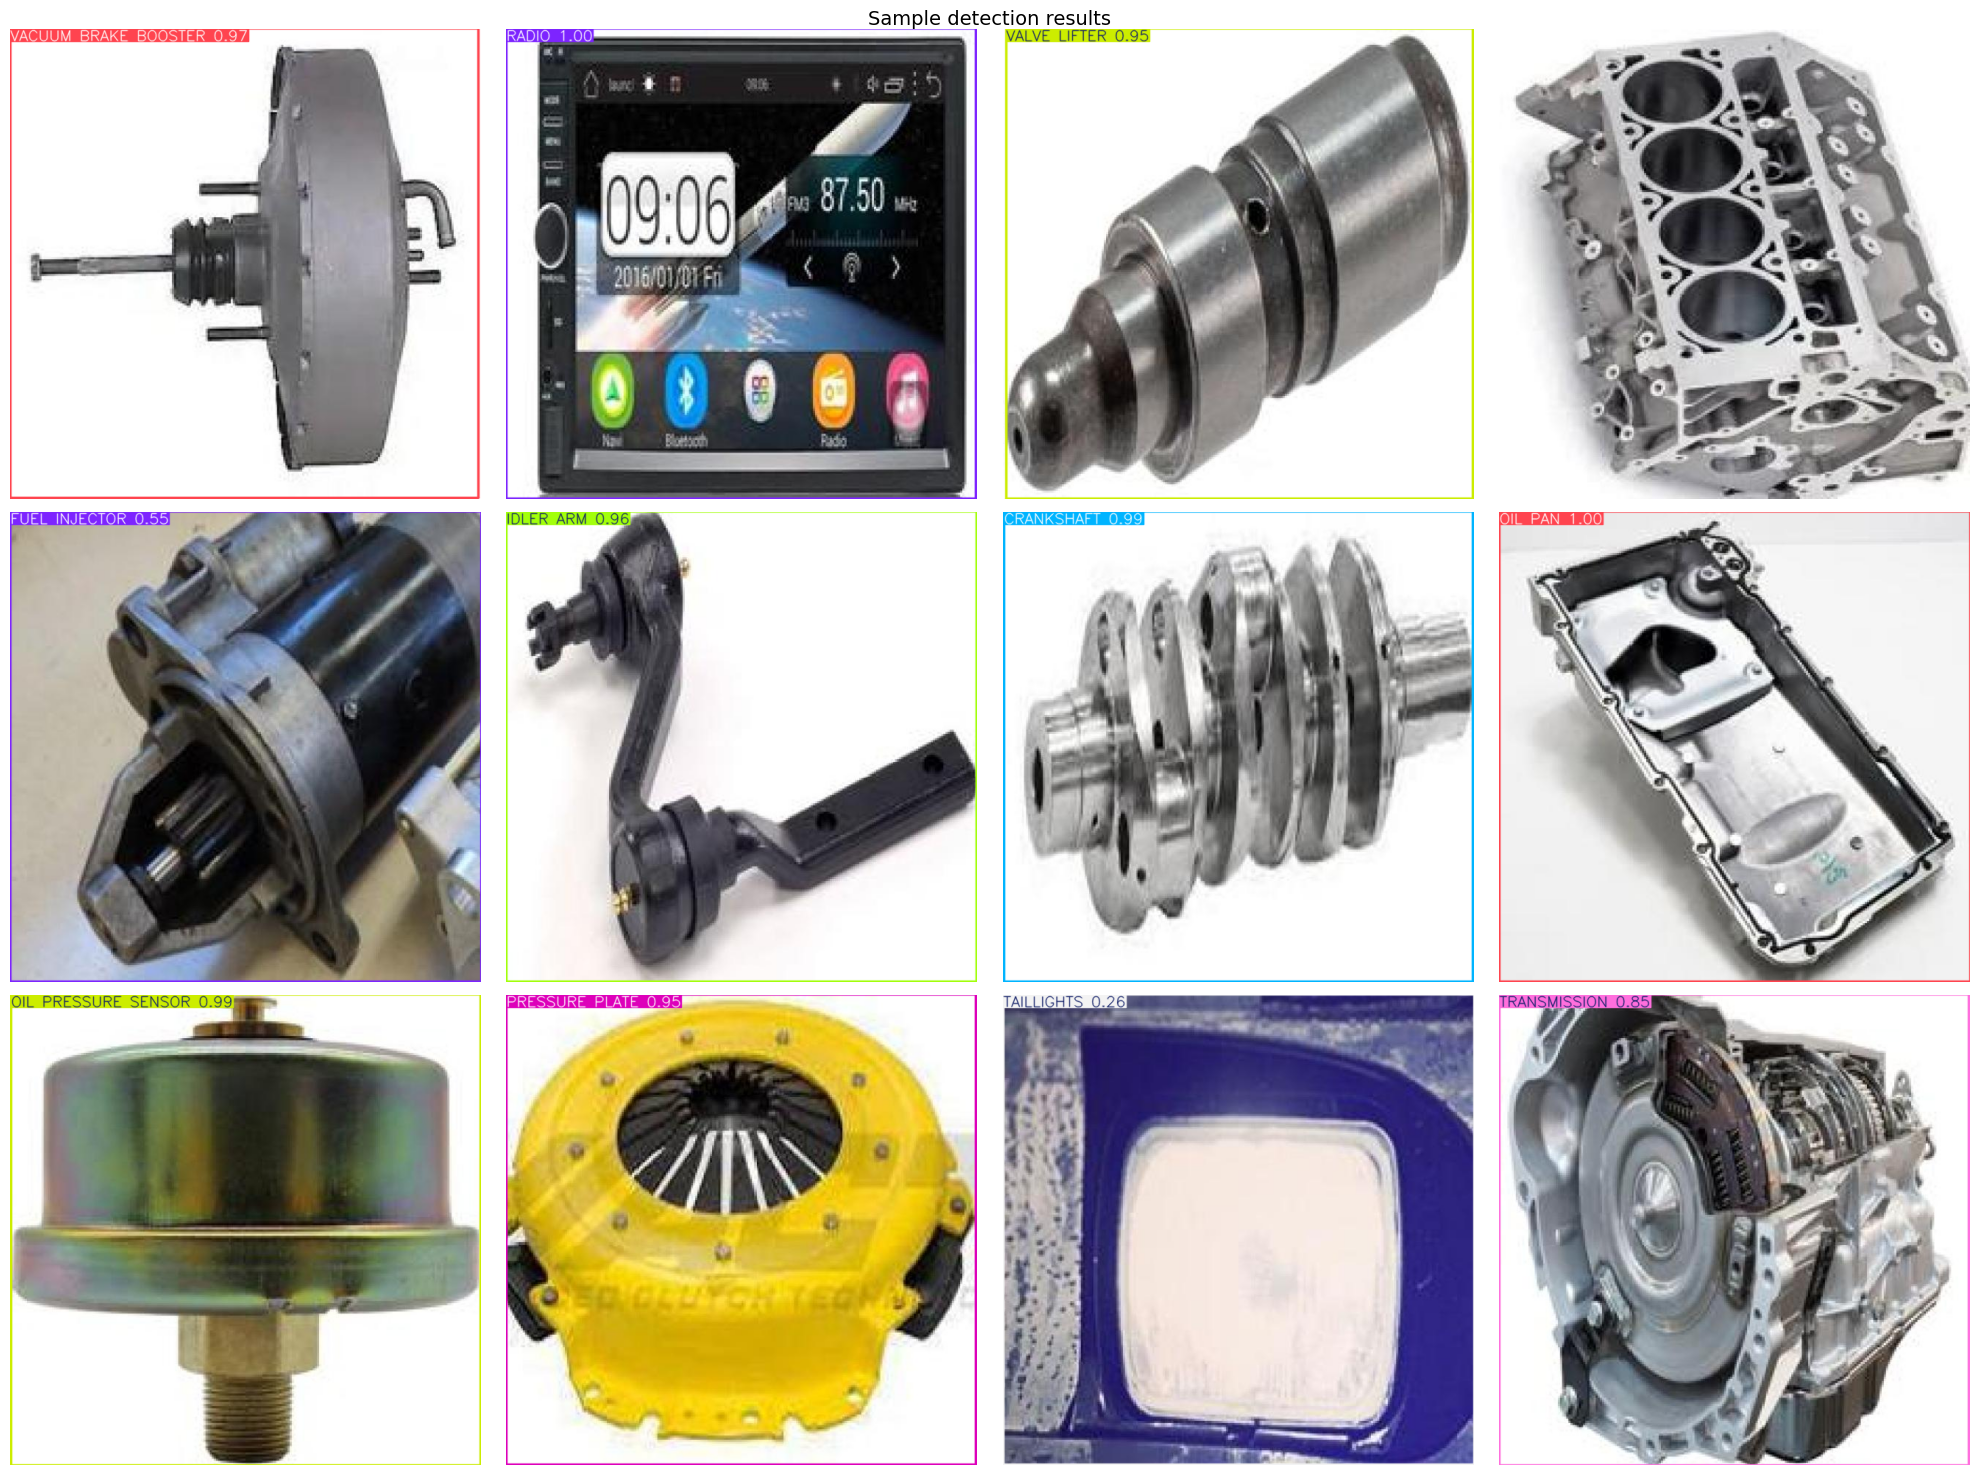

In [9]:
# Detection visualisations — sample predictions with bounding boxes
best_model_path = None
for candidate in [
    f'{OUTPUT_DIR}/runs/exp6_yolo26s/weights/best.pt',
    f'{OUTPUT_DIR}/runs/exp1_yolov8s_baseline/weights/best.pt',
]:
    if os.path.exists(candidate):
        best_model_path = candidate
        break

if best_model_path:
    vis_model = YOLO(best_model_path)
    test_images = glob.glob(f'{DATASET_DIR}/test/images/*')[:12]
    
    if not test_images:
        # Try nested path
        test_images = glob.glob(f'{DATASET_DIR}/*/test/images/*')[:12]
    
    if test_images:
        results = vis_model.predict(source=test_images, conf=0.25, save=True,
            project=f'{OUTPUT_DIR}/visualisations', name='detections', line_width=2)
        
        fig, axes = plt.subplots(3, 4, figsize=(20, 15))
        for ax, r in zip(axes.flat, results):
            img = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.axis('off')
        plt.suptitle('Sample detection results', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/sample_detections.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("No test images found.")
else:
    print("No trained model found. Run experiments first.")

In [10]:
# ONNX Export — prototype demonstration
if best_model_path:
    export_model = YOLO(best_model_path)
    onnx_path = export_model.export(format='onnx', imgsz=640)
    print(f"Model exported to ONNX: {onnx_path}")
    print("Mention this in Chapter 4 (Implementation) and Chapter 6 (Future Work)")
else:
    print("No model to export. Run experiments first.")

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s summary (fused): 122 layers, 9,484,530 parameters, 0 gradients, 20.6 GFLOPs

PyTorch: starting from '/kaggle/working/results/runs/exp6_yolo26s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 340ms
Prepared 2 packages in 2.85s
Installed 2 packages in 12ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 7.4s, saved as '/kaggle/working/results/runs/exp6_yolo26s/weights/best.onnx' (36.5 MB)

Export complete (8.2s)
Results saved to /kaggle/working/results/runs/exp6_yolo26s/weights
Predict:         yolo predict task=detect model=/kaggle/working/results/runs/exp6_yolo26s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/results/runs/exp6_yolo26s/weights/best.onnx imgsz=640 data=/kaggle/working/dataset/data.yaml  
Visualize:       https://netron.app
Model exported to ONNX: /kaggle/working/results/runs/exp6_yolo26s/weights/best.onnx
Mention this in Chapter 4 (Implementation) and Chapter 6 (Future Work)


In [11]:
# Final summary
print("="*70)
print("ALL FILES GENERATED")
print("="*70)
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*.*')):
    size = os.path.getsize(f)
    print(f"  {os.path.basename(f)} ({size//1024}KB)")
print(f"\nRun folders:")
for d in sorted(glob.glob(f'{OUTPUT_DIR}/runs/*')):
    if os.path.isdir(d):
        print(f"  {os.path.basename(d)}/")
print(f"\nDownload the entire '{OUTPUT_DIR}' folder to your local machine.")
print("Then push results to GitHub and use the charts in your dissertation.")

ALL FILES GENERATED
  all_experiments_comparison.csv (0KB)
  ch1_motivational_figure.png (166KB)
  exp5_transfer_learning.json (5KB)
  exp6_yolo26.json (2KB)
  hard_classes_chart.png (53KB)
  hard_classes_comparison.csv (0KB)
  sample_detections.png (4337KB)

Run folders:
  exp5_from_scratch/
  exp5_pretrained/
  exp6_yolo26s/

Download the entire '/kaggle/working/results' folder to your local machine.
Then push results to GitHub and use the charts in your dissertation.
